<a href="https://colab.research.google.com/github/pravee827/AI-ML/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

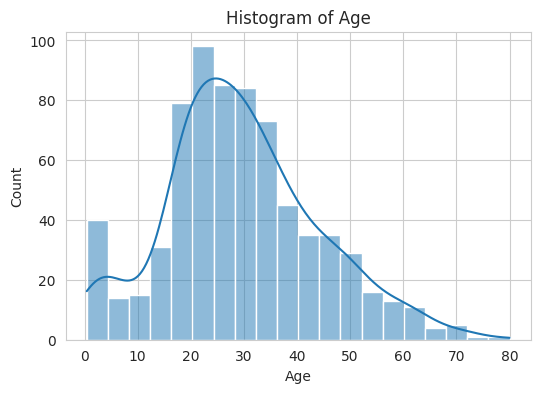

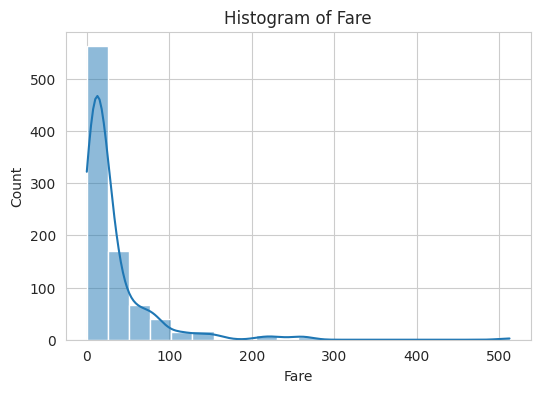

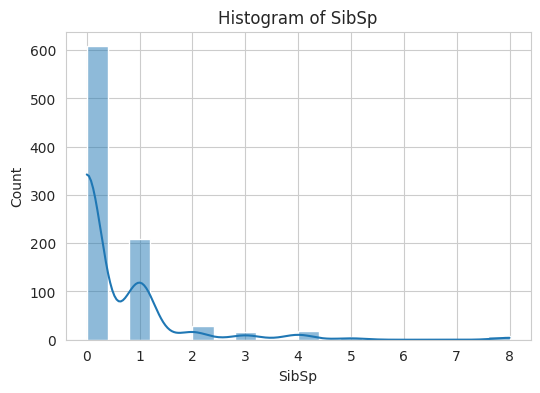

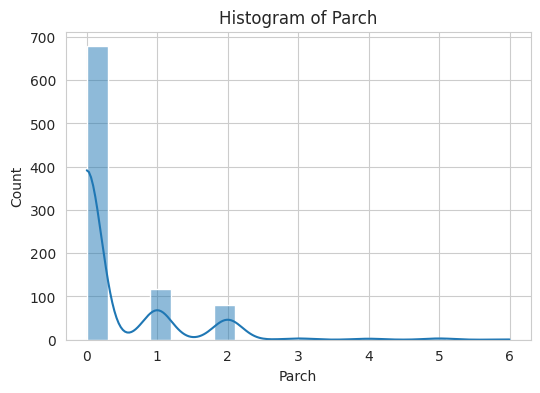

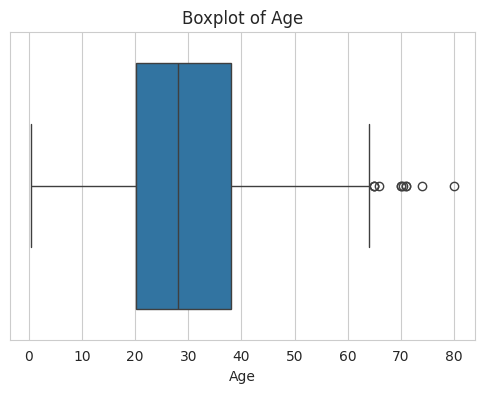

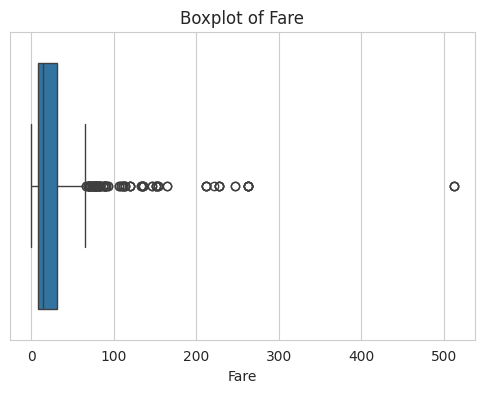

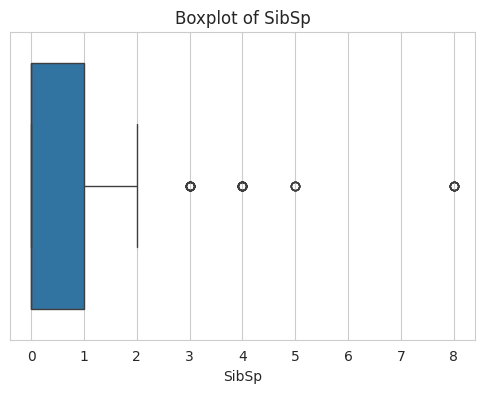

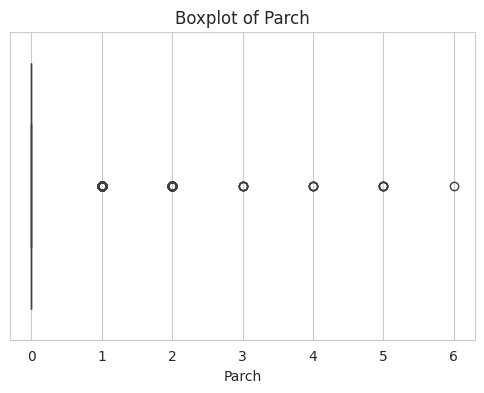


CORRELATION MATRIX
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


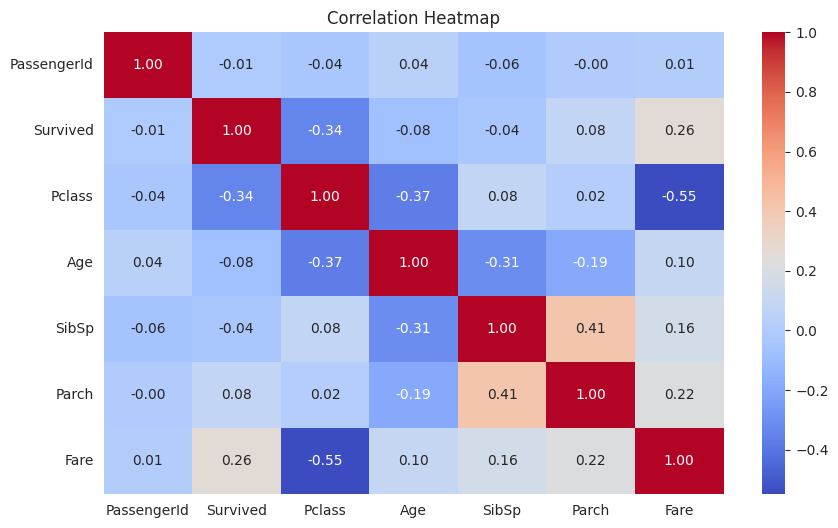

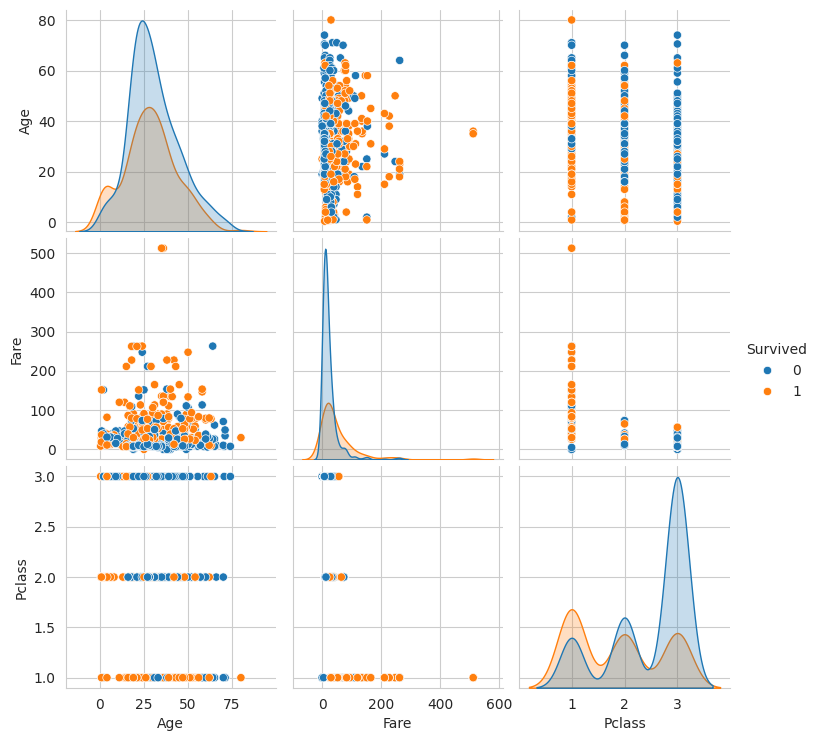

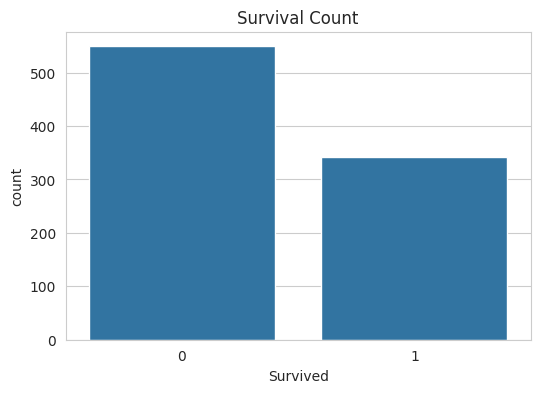

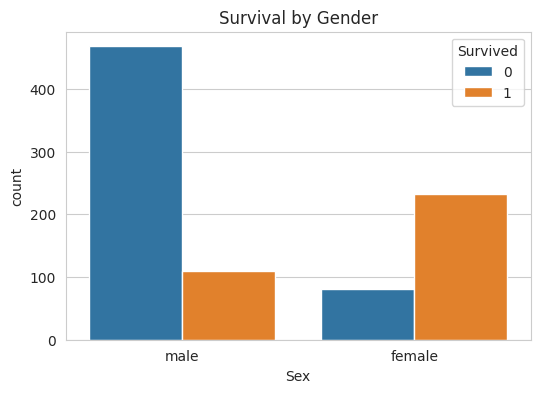

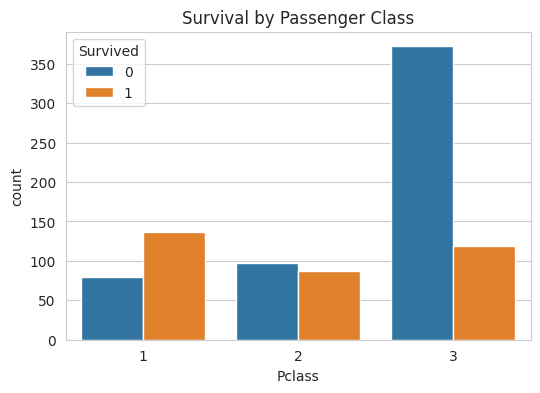

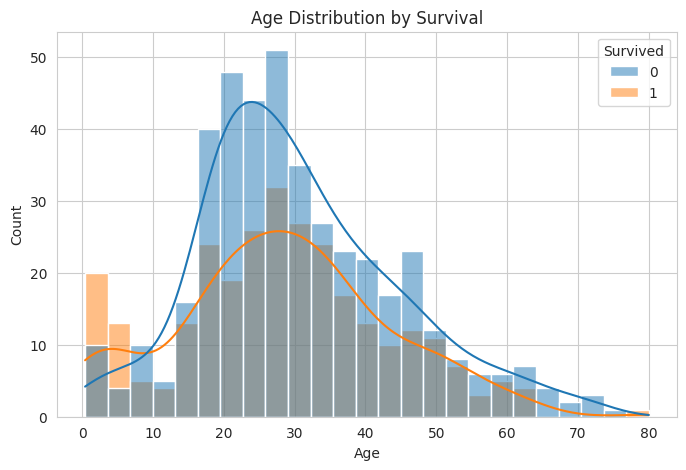

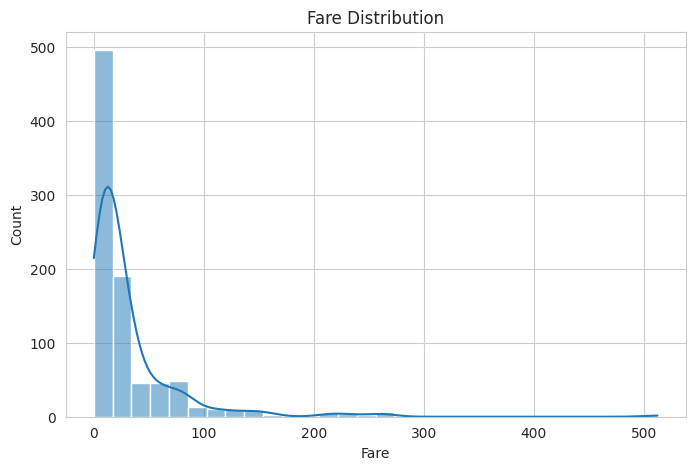


OUTLIER DETECTION USING IQR

Age
Number of Outliers: 11

Fare
Number of Outliers: 116

KEY INSIGHTS
1. Females had higher survival rates than males.
2. First-class passengers survived more often.
3. Fare has some relationship with survival.
4. Age contains missing values.
5. Fare contains several outliers.
6. Passenger class negatively correlates with survival.
7. Histograms reveal distribution and skewness.
8. Boxplots help identify extreme values.

EDA COMPLETED SUCCESSFULLY!


In [ ]:
# TASK 2 - EXPLORATORY DATA ANALYSIS (EDA)
# Titanic Dataset
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv("Titanic-Dataset.csv")

print("="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

# ==========================================
# Dataset Information
# ==========================================
print("\nDATASET INFO")
print(df.info())

print("\nSHAPE OF DATASET")
print(df.shape)

# ==========================================
# Missing Values
# ==========================================
print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# Summary Statistics
# ==========================================
print("\nSUMMARY STATISTICS")
print(df.describe())

# ==========================================
# Median Values
# ==========================================
print("\nMEDIAN VALUES")
print(df.median(numeric_only=True))

# ==========================================
# Data Types
# ==========================================
print("\nDATA TYPES")
print(df.dtypes)

# ==========================================
# Numerical Columns
# ==========================================
numerical_columns = [
    'Age',
    'Fare',
    'SibSp',
    'Parch'
]

# ==========================================
# Histograms
# ==========================================
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Histogram of {col}')
    plt.show()

# ==========================================
# Boxplots
# ==========================================
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# ==========================================
# Correlation Matrix
# ==========================================
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("\nCORRELATION MATRIX")
print(correlation_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Pairplot
# ==========================================
pairplot_columns = [
    'Survived',
    'Age',
    'Fare',
    'Pclass'
]

sns.pairplot(
    df[pairplot_columns].dropna(),
    hue='Survived'
)
plt.show()

# ==========================================
# Survival Count
# ==========================================
plt.figure(figsize=(6,4))
sns.countplot(
    x='Survived',
    data=df
)
plt.title("Survival Count")
plt.show()

# ==========================================
# Survival by Gender
# ==========================================
plt.figure(figsize=(6,4))
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)
plt.title("Survival by Gender")
plt.show()

# ==========================================
# Survival by Passenger Class
# ==========================================
plt.figure(figsize=(6,4))
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)
plt.title("Survival by Passenger Class")
plt.show()

# ==========================================
# Age Distribution by Survival
# ==========================================
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    kde=True,
    bins=25
)
plt.title("Age Distribution by Survival")
plt.show()

# ==========================================
# Fare Distribution
# ==========================================
plt.figure(figsize=(8,5))
sns.histplot(
    df['Fare'],
    bins=30,
    kde=True
)
plt.title("Fare Distribution")
plt.show()

# ==========================================
# Outlier Detection
# ==========================================
print("\nOUTLIER DETECTION USING IQR")

for col in ['Age', 'Fare']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print("Number of Outliers:", len(outliers))

# ==========================================
# Basic Inferences
# ==========================================
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

print("1. Females had higher survival rates than males.")
print("2. First-class passengers survived more often.")
print("3. Fare has some relationship with survival.")
print("4. Age contains missing values.")
print("5. Fare contains several outliers.")
print("6. Passenger class negatively correlates with survival.")
print("7. Histograms reveal distribution and skewness.")
print("8. Boxplots help identify extreme values.")

print("\nEDA COMPLETED SUCCESSFULLY!")